# notebooks/03_model_building.ipynb

In [377]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

## Load Model-Ready Data

In [378]:
DATA_PATH = os.path.join('..', 'data', 'panel_data_model_ready.parquet')

df = pd.read_parquet(DATA_PATH)
print(f'Data Shape: {df.shape}')
display(df.head())

Data Shape: (153515, 19)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                               
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909   3.771960   
           AMGN   2.460476  5.177506      5.177506       5.177506   3.635898   
           AMZN   5.818162  9.886836      9.886836       9.886836   8.018926   
           AXP    4.693210  4.448244      4.448244       4.448244   4.122573   
           BA     2.934207  7.469396      7.469396       7.469396   7.016747   

                  bpv_rolling_5  good_lag_1  bad_lag_1  bad_lag_5    rq_lag_1  \
Date       Stock                                                                
2003-01-03 AAPL        3.771960    5.102315   1.391595   2.164027  152.729402   
           AMGN        3.635898    3.362921   1.814585   1.539232   46.168213   
           AMZN        8.018926    6.074276   3.812559   2.645363  200.751309   
           AXP         4.122573    3.337253   1.110991   1.390094  114.695371   
           BA          7.016747    5.107386   2.362010   2.011010  150.112379   

                  vix_lag_1  rv_vix_interaction  bad_rv_interaction  
Date       Stock                                                     
2003-01-03 AAPL       25.39          164.880356            9.036889  
           AMGN       25.39          131.456870            9.395025  
           AMZN       25.39          251.026754           37.694144  
           AXP        25.39          112.940920            4.941961  
           BA         25.39          189.647958           17.642785

## Define Features (X) and Target (Y)

In [379]:
Y = df['Y_reg']

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]

X_advanced = df.drop(columns=['rv', 'bpv', 'good', 'bad', 'rq', 'vix', 'Y_reg'])

print(f'Target (Y) shape: {Y.shape}')
print(f'HAR Features (X_har) shape: {X_har.shape}')
print(f'Advanced Features (X_advanced) shape: {X_advanced.shape}')
display(X_har.head())

Target (Y) shape: (153515,)
HAR Features (X_har) shape: (153515, 3)
Advanced Features (X_advanced) shape: (153515, 12)


rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2003-01-03 AAPL   6.493909      6.493909       6.493909
           AMGN   5.177506      5.177506       5.177506
           AMZN   9.886836      9.886836       9.886836
           AXP    4.448244      4.448244       4.448244
           BA     7.469396      7.469396       7.469396

## Setup Rolling Window Validation

Initialized TimeSeriesSplit with 2 splits.


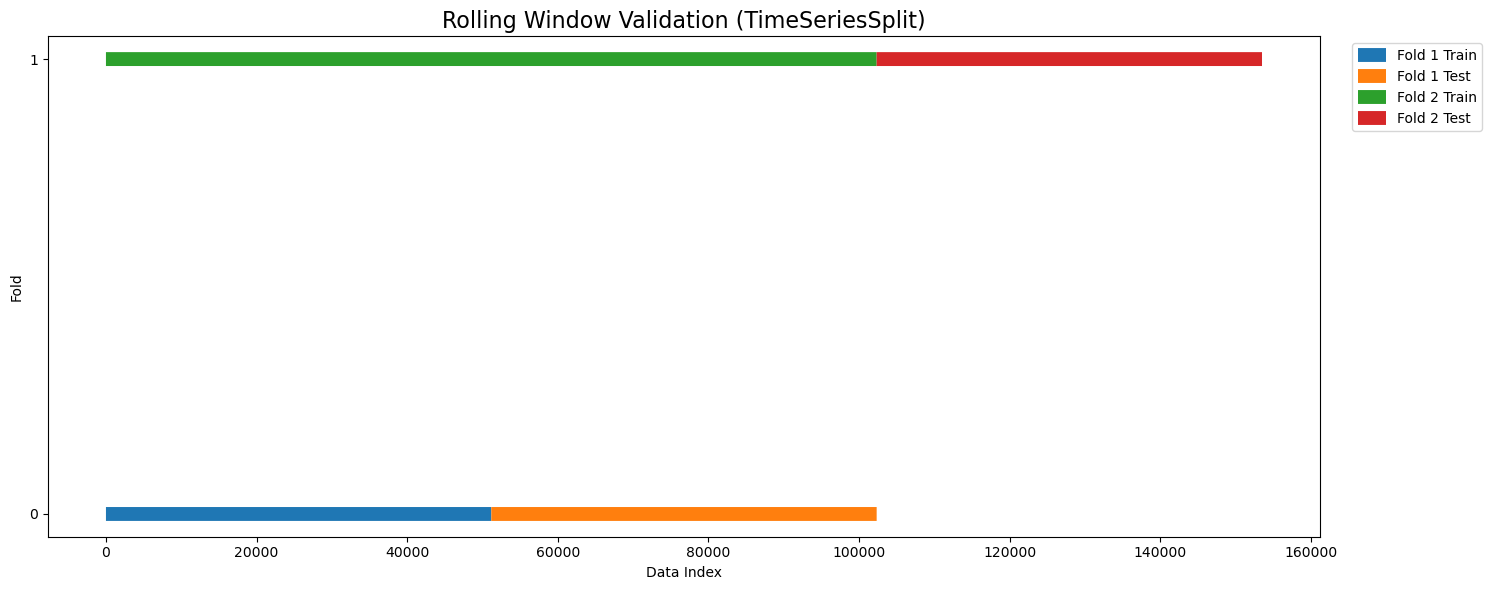

In [380]:
N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'Initialized TimeSeriesSplit with {N_SPLITS} splits.')

fig, ax = plt.subplots(figsize=(15, 6))
for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    ax.plot(train_index, [i] * len(train_index), label=f'Fold {i+1} Train', lw=10, solid_capstyle='butt')
    ax.plot(test_index, [i] * len(test_index), label=f'Fold {i+1} Test', lw=10, solid_capstyle='butt')

ax.set_title('Rolling Window Validation (TimeSeriesSplit)', fontsize=16)
ax.set_xlabel('Data Index')
ax.set_ylabel('Fold')
ax.set_yticks(range(N_SPLITS))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train & Evaluate HAR Baseline

In [381]:
Y = df['Y_reg'] 
har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]

Y_log = np.log1p(Y)
X_har_log = np.log1p(X_har)
har_mse_scores_log = []
har_models_log = []

print('\nTraining & Evaluation for HAR (Log-Log Specification)...')

for i, (train_index, test_index) in enumerate(tscv.split(X_har_log)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_har_log.iloc[train_index], X_har_log.iloc[test_index]
    y_train_log, y_test_log = Y_log.iloc[train_index], Y_log.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    har_model_log = LinearRegression()
    har_model_log.fit(X_train, y_train_log)
    
    y_pred_log = har_model_log.predict(X_test)
    
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    
    y_pred_orig[y_pred_orig < 0] = 0 
    
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    
    har_mse_scores_log.append(mse)
    har_models_log.append(har_model_log)
    
    print(f"  Fold {i+1} MSE (Original Scale): {mse:.6f}")
    
average_har_mse_log = np.mean(har_mse_scores_log)

print(f"\nAverage HAR Model MSE (Log-Log Trained): {average_har_mse_log:.6f}")


Training & Evaluation for HAR (Log-Log Specification)...
--- Fold 1/2 ---
  Train size: 51173, Test size: 51171
  Fold 1 MSE (Original Scale): 4.912242
--- Fold 2/2 ---
  Train size: 102344, Test size: 51171
  Fold 2 MSE (Original Scale): 14.973623

Average HAR Model MSE (Log-Log Trained): 9.942932


In [382]:
import joblib
MODEL_PATH = os.path.join("..", "models")

final_har_model = har_models_log[-1]
har_model_filename = os.path.join(MODEL_PATH, "har_baseline_model.joblib")
joblib.dump(final_har_model, har_model_filename)

print(f"Final HAR model saved to: {har_model_filename}")

Final HAR model saved to: ../models/har_baseline_model.joblib


## Isolation Forest Part

In [383]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [384]:
MODEL_PATH = os.path.join("..", "models", "har_baseline_model.joblib")

har_model = joblib.load(MODEL_PATH)

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
X_har = df[har_features]
Y_reg = df['Y_reg']

## Calculate Model Residuals (Errors)

In [385]:
har_predictions = har_model.predict(X_har)
df['har_error'] = Y_reg - har_predictions
print("HAR model residuals calculated.")
display(df[['Y_reg', 'har_error']].describe())

HAR model residuals calculated.


,Y_reg,har_error
count,153515.000000,153515.000000
mean,2.315558,0.165175
std,5.565324,4.210541
min,0.045685,-129.044338
25%,0.677630,-0.450093
50%,1.184212,-0.105003
75%,2.213203,0.336355
max,400.349507,349.902160


## Standardize Residuals

In [386]:
scaler = StandardScaler()
df['error_scaled'] = df.groupby(level='Stock')['har_error'].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())

print("Residuals have been standardized per stock.")
display(df[['har_error', 'error_scaled']].head())

Residuals have been standardized per stock.


har_error  error_scaled
Date       Stock                         
2003-01-03 AAPL    0.092520     -0.033875
           AMGN   -2.256294     -0.783057
           AMZN   -3.130603     -0.866341
           AXP     0.631783      0.070413
           BA     -3.842149     -0.673634

## Train the Isolation Forest

In [387]:
train_end_date = '2019-12-31'
train_data = df.loc[df.index.get_level_values('Date') <= train_end_date]

X_train_errors = train_data['error_scaled'].values.reshape(-1, 1)
print(f"Training Isolation Forest on {len(X_train_errors)} data points...")

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_errors)

Training Isolation Forest on 121535 data points...


,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


## Create Anomaly Labels (Y_class)

In [388]:
X_all_errors = df['error_scaled'].values.reshape(-1, 1)

anomaly_predictions = iso_forest.predict(X_all_errors)

df['is_abnormal'] = np.where(anomaly_predictions == -1, 1, 0)

abnormal_pct = df['is_abnormal'].mean() * 100
print(f"Total anomalies detected across all data: {df['is_abnormal'].sum()}")
print(f"Percentage of anomalies: {abnormal_pct:.2f}%")

display(df[['har_error', 'error_scaled', 'is_abnormal']].head())

Total anomalies detected across all data: 8205
Percentage of anomalies: 5.34%


har_error  error_scaled  is_abnormal
Date       Stock                                      
2003-01-03 AAPL    0.092520     -0.033875            0
           AMGN   -2.256294     -0.783057            0
           AMZN   -3.130603     -0.866341            0
           AXP     0.631783      0.070413            0
           BA     -3.842149     -0.673634            0

## Visualize and Validate the Anomalies

Anomalies found for AAPL: 422


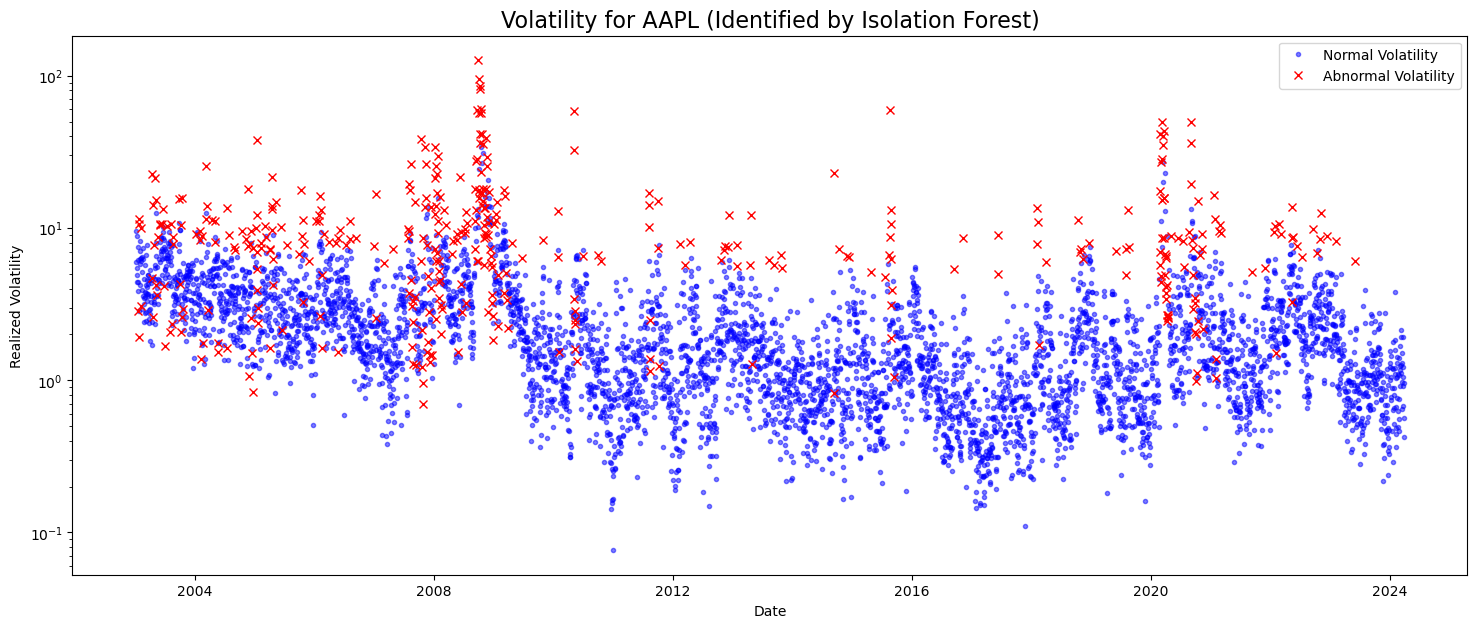

In [389]:
stock_to_plot = 'AAPL'
df_stock = df.loc[pd.IndexSlice[:, stock_to_plot], :]

anomalies = df_stock[df_stock['is_abnormal'] == 1]
normals = df_stock[df_stock['is_abnormal'] == 0]

print(f"Anomalies found for {stock_to_plot}: {len(anomalies)}")

plt.figure(figsize=(18, 7))
plt.plot(
    normals.index.get_level_values('Date'), 
    normals['Y_reg'], 
    linestyle='None', 
    marker='.', 
    color='blue', 
    alpha=0.5, 
    label='Normal Volatility'
)
plt.plot(
    anomalies.index.get_level_values('Date'), 
    anomalies['Y_reg'], 
    linestyle='None', 
    marker='x', 
    color='red', 
    label='Abnormal Volatility'
)

plt.title(f'Volatility for {stock_to_plot} (Identified by Isolation Forest)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.legend()
plt.yscale('log')
plt.show()

In [390]:
df['Y_class'] = df.groupby('Stock')['is_abnormal'].shift(-1)

df_model_ready_phase4 = df.dropna()

print(f"Original data size: {df.shape}")
print(f"Final data size for Phase 4: {df_model_ready_phase4.shape}")

output_path = os.path.join("..", "data", "panel_data_phase4_ready.parquet")
df_model_ready_phase4.to_parquet(output_path)
display(df_model_ready_phase4.head())

Original data size: (153515, 23)
Final data size for Phase 4: (153485, 23)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909  ...   
           AMGN   2.460476  5.177506      5.177506       5.177506  ...   
           AMZN   5.818162  9.886836      9.886836       9.886836  ...   
           AXP    4.693210  4.448244      4.448244       4.448244  ...   
           BA     2.934207  7.469396      7.469396       7.469396  ...   

                  bad_lag_1  bad_lag_5    rq_lag_1  vix_lag_1  \
Date       Stock                                                
2003-01-03 AAPL    1.391595   2.164027  152.729402      25.39   
           AMGN    1.814585   1.539232   46.168213      25.39   
           AMZN    3.812559   2.645363  200.751309      25.39   
           AXP     1.110991   1.390094  114.695371      25.39   
           BA      2.362010   2.011010  150.112379      25.39   

                  rv_vix_interaction  bad_rv_interaction  har_error  \
Date       Stock                                                      
2003-01-03 AAPL           164.880356            9.036889   0.092520   
           AMGN           131.456870            9.395025  -2.256294   
           AMZN           251.026754           37.694144  -3.130603   
           AXP            112.940920            4.941961   0.631783   
           BA             189.647958           17.642785  -3.842149   

                  error_scaled  is_abnormal  Y_class  
Date       Stock                                      
2003-01-03 AAPL      -0.033875            0      0.0  
           AMGN      -0.783057            0      0.0  
           AMZN      -0.866341            0      0.0  
           AXP        0.070413            0      0.0  
           BA        -0.673634            0      0.0  

[5 rows x 23 columns]

## Advanced ML Modeling & Interpretation

In [391]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import shap

import warnings
warnings.filterwarnings('ignore')

In [392]:
print("Loaded advanced modeling libraries (XGBoost, SHAP).")

PHASE_4_DATA_PATH = os.path.join('..', 'data', 'panel_data_phase4_ready.parquet')
df = pd.read_parquet(PHASE_4_DATA_PATH)

print(f"Loaded Phase 4 data: {df.shape}")
display(df.head())

Loaded advanced modeling libraries (XGBoost, SHAP).
Loaded Phase 4 data: (153485, 23)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  ...  \
Date       Stock                                                   ...   
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909  ...   
           AMGN   2.460476  5.177506      5.177506       5.177506  ...   
           AMZN   5.818162  9.886836      9.886836       9.886836  ...   
           AXP    4.693210  4.448244      4.448244       4.448244  ...   
           BA     2.934207  7.469396      7.469396       7.469396  ...   

                  bad_lag_1  bad_lag_5    rq_lag_1  vix_lag_1  \
Date       Stock                                                
2003-01-03 AAPL    1.391595   2.164027  152.729402      25.39   
           AMGN    1.814585   1.539232   46.168213      25.39   
           AMZN    3.812559   2.645363  200.751309      25.39   
           AXP     1.110991   1.390094  114.695371      25.39   
           BA      2.362010   2.011010  150.112379      25.39   

                  rv_vix_interaction  bad_rv_interaction  har_error  \
Date       Stock                                                      
2003-01-03 AAPL           164.880356            9.036889   0.092520   
           AMGN           131.456870            9.395025  -2.256294   
           AMZN           251.026754           37.694144  -3.130603   
           AXP            112.940920            4.941961   0.631783   
           BA             189.647958           17.642785  -3.842149   

                  error_scaled  is_abnormal  Y_class  
Date       Stock                                      
2003-01-03 AAPL      -0.033875            0      0.0  
           AMGN      -0.783057            0      0.0  
           AMZN      -0.866341            0      0.0  
           AXP        0.070413            0      0.0  
           BA        -0.673634            0      0.0  

[5 rows x 23 columns]

In [393]:
Y_reg = df['Y_reg']
Y_reg_log = np.log1p(Y_reg)

Y_class = df['Y_class']

non_feature_cols = [
    'rv', 'bpv', 'good', 'bad', 'rq', 'vix',
    'Y_reg',                                 
    'har_error', 'error_scaled', 'is_abnormal',
    'Y_class'                               
]
X_advanced = df.drop(columns=non_feature_cols)
X_advanced_log = np.log1p(X_advanced)

print(f"Advanced Features (X_advanced) shape: {X_advanced.shape}")
print(f"Regression Target (Y_reg) shape: {Y_reg.shape}")
print(f"Classification Target (Y_class) shape: {Y_class.shape}")
display(X_advanced.head())

Advanced Features (X_advanced) shape: (153485, 12)
Regression Target (Y_reg) shape: (153485,)
Classification Target (Y_class) shape: (153485,)


rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                     
2003-01-03 AAPL   6.493909      6.493909       6.493909   3.771960   
           AMGN   5.177506      5.177506       5.177506   3.635898   
           AMZN   9.886836      9.886836       9.886836   8.018926   
           AXP    4.448244      4.448244       4.448244   4.122573   
           BA     7.469396      7.469396       7.469396   7.016747   

                  bpv_rolling_5  good_lag_1  bad_lag_1  bad_lag_5    rq_lag_1  \
Date       Stock                                                                
2003-01-03 AAPL        3.771960    5.102315   1.391595   2.164027  152.729402   
           AMGN        3.635898    3.362921   1.814585   1.539232   46.168213   
           AMZN        8.018926    6.074276   3.812559   2.645363  200.751309   
           AXP         4.122573    3.337253   1.110991   1.390094  114.695371   
           BA          7.016747    5.107386   2.362010   2.011010  150.112379   

                  vix_lag_1  rv_vix_interaction  bad_rv_interaction  
Date       Stock                                                     
2003-01-03 AAPL       25.39          164.880356            9.036889  
           AMGN       25.39          131.456870            9.395025  
           AMZN       25.39          251.026754           37.694144  
           AXP        25.39          112.940920            4.941961  
           BA         25.39          189.647958           17.642785

In [394]:
## --- Setup Validation ---
N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

## XGBoost

In [395]:
print("--- Starting Task 4.1: Advanced Regression (XGBoost) ---")

X_train_data = X_advanced 
y_train_data = Y_reg_log

xgb_reg_mse_scores = []
xgb_reg_models = []

for i, (train_index, test_index) in enumerate(tscv.split(X_train_data)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')

    X_train, X_test = X_train_data.iloc[train_index], X_train_data.iloc[test_index]
    y_train_log, y_test_log = y_train_data.iloc[train_index], y_train_data.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    xgb_reg = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=126,
        learning_rate=0.05,
        max_depth=7,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_reg.fit(X_train, y_train_log)
    
    y_pred_log = xgb_reg.predict(X_test)
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)
    
    y_pred_orig[y_pred_orig < 0] = 0 
    
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    xgb_reg_mse_scores.append(mse)
    xgb_reg_models.append(xgb_reg)
    
    print(f"  Fold {i+1} MSE (Original Scale): {mse:.6f}")

avg_xgb_mse = np.mean(xgb_reg_mse_scores)

print("\n--- Regression Model Comparison ---")
print(f"  Average HAR Model MSE (Log-Log):     {average_har_mse_log:.6f}")
print(f"  Average XGB Regressor MSE:           {avg_xgb_mse:.6f}")

improvement = (average_har_mse_log - avg_xgb_mse) / average_har_mse_log
print(f"\n  Improvement over HAR: {improvement:.2%}")

--- Starting Task 4.1: Advanced Regression (XGBoost) ---
--- Fold 1/2 ---
  Train size: 51163, Test size: 51161
  Fold 1 MSE (Original Scale): 4.682315
--- Fold 2/2 ---
  Train size: 102324, Test size: 51161
  Fold 2 MSE (Original Scale): 13.489455

--- Regression Model Comparison ---
  Average HAR Model MSE (Log-Log):     9.942932
  Average XGB Regressor MSE:           9.085885

  Improvement over HAR: 8.62%


## Anomaly Classification (XGBoost)


--- Starting Task 4.2: Anomaly Classification (XGBoost) ---
--- Fold 1/2 ---
  Train size: 51163, Test size: 51161
  Train Abnormal Pct: 8.65%, Test Abnormal Pct: 2.21%
  Calculated scale_pos_weight: 10.56
--- Fold 2/2 ---
  Train size: 102324, Test size: 51161
  Train Abnormal Pct: 5.43%, Test Abnormal Pct: 5.17%
  Calculated scale_pos_weight: 17.42

--- Final Fold Classification Report (Task 4.2) ---
              precision    recall  f1-score   support

  Normal (0)       0.97      0.98      0.97     48518
Abnormal (1)       0.49      0.41      0.45      2643

    accuracy                           0.95     51161
   macro avg       0.73      0.69      0.71     51161
weighted avg       0.94      0.95      0.95     51161


--- Final Fold Confusion Matrix (Task 4.2) ---


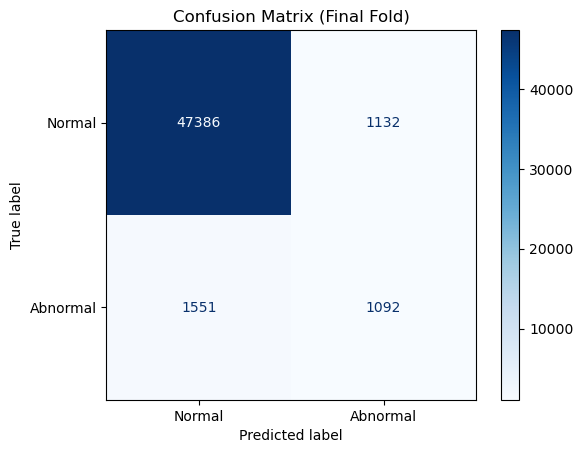

In [396]:
print("\n--- Starting Task 4.2: Anomaly Classification (XGBoost) ---")

xgb_class_reports = []
xgb_class_models = []
last_fold_data = {}

for i, (train_index, test_index) in enumerate(tscv.split(X_advanced)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_advanced.iloc[train_index], X_advanced.iloc[test_index]
    y_train, y_test = Y_class.iloc[train_index], Y_class.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"  Train Abnormal Pct: {y_train.mean():.2%}, Test Abnormal Pct: {y_test.mean():.2%}")
    
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"  Calculated scale_pos_weight: {scale_pos_weight:.2f}")

    xgb_class = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    n_estimators=126,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss',
)

    
    xgb_class.fit(X_train, y_train)
    
    y_prob = xgb_class.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.8).astype(int)   

    
    report = classification_report(y_test, y_pred, target_names=['Normal (0)', 'Abnormal (1)'])
    
    xgb_class_reports.append(report)
    xgb_class_models.append(xgb_class)
    
    if i == N_SPLITS - 1:
        last_fold_data['X_test'] = X_test
        last_fold_data['y_test'] = y_test
        last_fold_data['y_pred'] = y_pred

print("\n--- Final Fold Classification Report (Task 4.2) ---")
print(xgb_class_reports[-1])

print("\n--- Final Fold Confusion Matrix (Task 4.2) ---")
cm = confusion_matrix(
    last_fold_data['y_test'], 
    last_fold_data['y_pred'], 
    labels=xgb_class_models[-1].classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Normal', 'Abnormal']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Final Fold)')
plt.show()

In [397]:
print("\n--- Practical Application ---")
print("Demonstrating how to use predict_proba() on a sample day.")

N_SPLITS = 2
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

all_indices = list(tscv.split(X_advanced))
train_index, test_index = all_indices[-1]

X_test_final_fold = X_advanced.iloc[test_index]

final_xgb_class = xgb_class_models[-1]

print(f"Loaded final classifier model and test data (shape: {X_test_final_fold.shape}).")

X_today_sample = X_test_final_fold.iloc[[10]] 
sample_index = X_today_sample.index[0]

probabilities = final_xgb_class.predict_proba(X_today_sample)

prob_normal = probabilities[0][0]
prob_abnormal = probabilities[0][1]

print(f"\n--- Prediction for Sample Day (Index: {sample_index}) ---")
print(f"  Model's predicted probability of 'Normal':   {prob_normal:.2%}")
print(f"  Model's predicted probability of 'Abnormal': {prob_abnormal:.2%}")

print("\n  Decision based on thresholds:")
if prob_abnormal > 0.75:
    print("  -> RESULT: High Confidence. 'Abnormal' day with high probability.")
elif prob_abnormal > 0.50:
    print("  -> RESULT: Model is flagging this (corresponds to the 24% precision).")
else:
    print("  -> RESULT: Model considers this a 'Normal' day.")


--- Practical Application ---
Demonstrating how to use predict_proba() on a sample day.
Loaded final classifier model and test data (shape: (51161, 12)).

--- Prediction for Sample Day (Index: (Timestamp('2017-05-24 00:00:00'), 'MSFT')) ---
  Model's predicted probability of 'Normal':   97.92%
  Model's predicted probability of 'Abnormal': 2.08%

  Decision based on thresholds:
  -> RESULT: Model considers this a 'Normal' day.


## SHAP


--- Starting Task 4.3: Model Interpretation (SHAP) ---
  Calculating SHAP for XGBRegressor (Final Fold)...
  Plotting Regression Feature Importance...


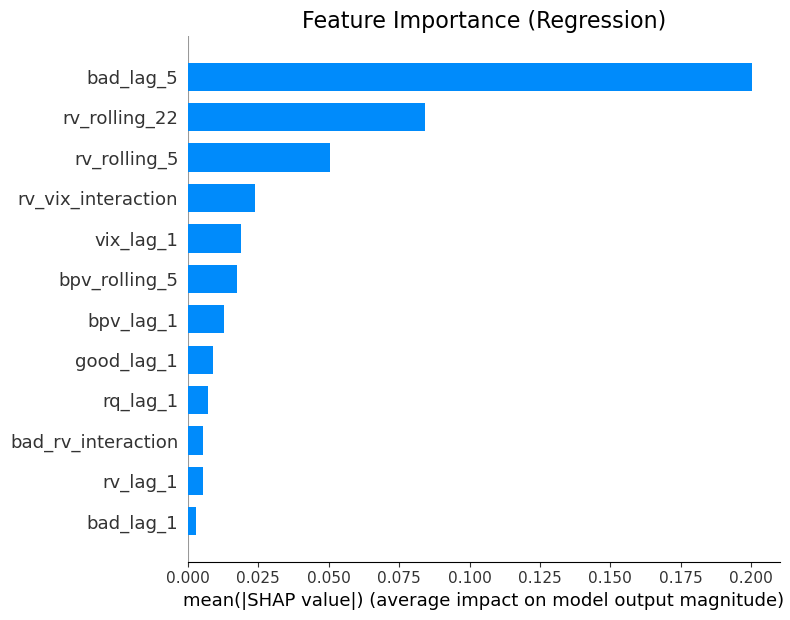

  Plotting Regression SHAP Summary...


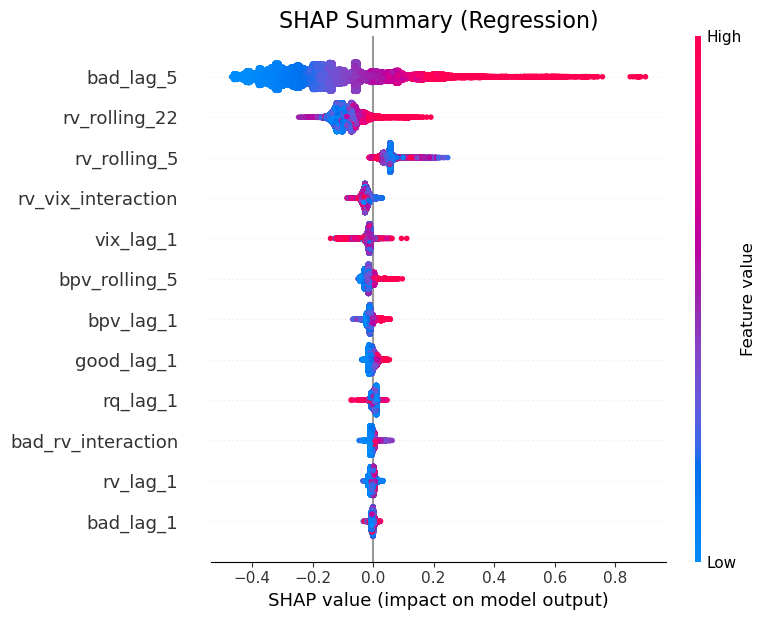


  Calculating SHAP for XGBClassifier (Final Fold)...
  Plotting Classification Feature Importance...


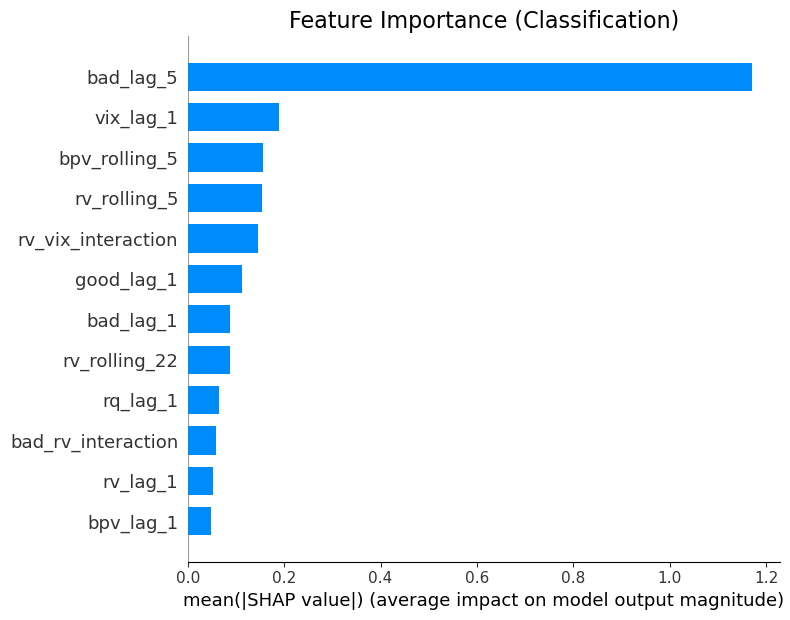

  Plotting Classification SHAP Summary...


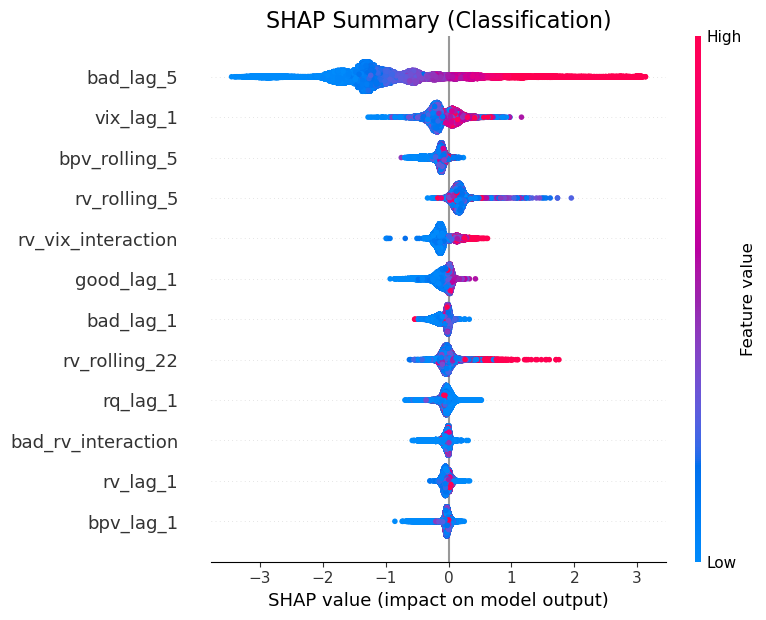

In [398]:
print("\n--- Starting Task 4.3: Model Interpretation (SHAP) ---")
print("  Calculating SHAP for XGBRegressor (Final Fold)...")

final_xgb_reg = xgb_reg_models[-1]
_, test_index_reg = list(tscv.split(X_advanced_log))[-1]
X_test_reg = X_advanced_log.iloc[test_index_reg]

explainer_reg = shap.TreeExplainer(final_xgb_reg)
shap_values_reg = explainer_reg(X_test_reg)

print("  Plotting Regression Feature Importance...")
plt.title('Feature Importance (Regression)', fontsize=16)
shap.summary_plot(shap_values_reg, X_test_reg, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("  Plotting Regression SHAP Summary...")
plt.title('SHAP Summary (Regression)', fontsize=16)
shap.summary_plot(shap_values_reg, X_test_reg, show=False)
plt.tight_layout()
plt.show()


print("\n  Calculating SHAP for XGBClassifier (Final Fold)...")

final_xgb_class = xgb_class_models[-1]
X_test_class = last_fold_data['X_test']

explainer_class = shap.TreeExplainer(final_xgb_class)
shap_values_class = explainer_class(X_test_class)

print("  Plotting Classification Feature Importance...")
plt.title('Feature Importance (Classification)', fontsize=16)
shap.summary_plot(shap_values_class, X_test_class, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

print("  Plotting Classification SHAP Summary...")
plt.title('SHAP Summary (Classification)', fontsize=16)
shap.summary_plot(shap_values_class, X_test_class, show=False)
plt.tight_layout()
plt.show()

## Deployment: Predicting "Tomorrow's" Volatility

In [399]:
print("\n--- Real-World Deployment: Predicting Next Day's Volatility ---")

# 1. Get the latest data point for a specific stock (e.g., 'AAPL')
stock_ticker = 'AAPL'
latest_data = df.xs(stock_ticker, level='Stock').iloc[[-1]] 
current_date = latest_data.index[0]

print(f"Generating forecast for {stock_ticker} using data from {current_date.date()}...")

# 2. Prepare the features (Raw)
feature_cols = X_advanced.columns
X_latest = latest_data[feature_cols]

# 3. Predict with Regressor (Forecast Value)
pred_log_rv = final_xgb_reg.predict(X_latest)[0]
pred_rv = np.expm1(pred_log_rv)

prob_abnormal = final_xgb_class.predict_proba(X_latest)[0][1]

print("\n" + "="*40)
print(f"  FORECAST REPORT FOR {stock_ticker}")
print("="*40)
print(f"  Predicted Realized Volatility: {pred_rv:.6f}")
print(f"  Abnormal Regime Probability:   {prob_abnormal:.2%}")

if prob_abnormal > 0.50:
    print("WARNING: High risk of abnormal volatility detected.")
else:
    print("STATUS: Market regime expected to be normal.")
print("="*40)


--- Real-World Deployment: Predicting Next Day's Volatility ---
Generating forecast for AAPL using data from 2024-03-26...

  FORECAST REPORT FOR AAPL
  Predicted Realized Volatility: 1.042338
  Abnormal Regime Probability:   18.29%
STATUS: Market regime expected to be normal.
